In [1]:
import ssl
import nltk
# Fix SSL certificate issue for NLTK downloads
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

DATA_PROCESSED = Path('data/processed')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / 'ea_ml_panel.csv')
df = df.sort_values(['country', 'year']).reset_index(drop=True)

print('Panel shape:', df.shape)
df[['country', 'year', 'birth_rate', 'mean_age_first_marriage', 'hicp_growth', 'hpi_growth', 'gdp_growth', 'unemp_rate']].head()

Panel shape: (109, 24)


,country,year,birth_rate,mean_age_first_marriage,hicp_growth,hpi_growth,gdp_growth,unemp_rate
0,Austria,2017,10.0,32.85,2.228385,5.088558,2.3,5.466667
1,Austria,2018,9.7,33.00,2.121682,5.965757,2.5,4.866667
2,Austria,2019,9.6,33.35,1.489422,6.008584,1.8,4.500000
3,Austria,2023,8.5,34.00,21.891942,29.935699,-0.8,5.100000
4,Belgium,2022,9.8,33.85,10.339271,5.533503,4.0,5.566667


In [2]:
# ── STEP 1: Generate Economic Narratives ──────────────────────────────────────
#
# Each (country, year) row is converted into a descriptive English sentence
# using the actual numerical values. This bridges structured data and NLP:
# the same information is now in a form that text-based models can process.

def describe_inflation(v):
    if v > 8:   return 'extremely high inflation'
    if v > 4:   return 'high inflation'
    if v > 2:   return 'moderate inflation'
    if v > 0:   return 'low inflation'
    return 'deflation'

def describe_hpi(v):
    if v > 10:  return 'rapidly rising housing prices'
    if v > 4:   return 'rising housing prices'
    if v > 0:   return 'stable housing prices'
    return 'falling housing prices'

def describe_gdp(v):
    if v > 4:   return 'strong economic growth'
    if v > 1:   return 'moderate economic growth'
    if v > -1:  return 'stagnant economy'
    return 'economic recession'

def describe_unemp(v):
    if v > 15:  return 'very high unemployment'
    if v > 8:   return 'high unemployment'
    if v > 5:   return 'moderate unemployment'
    return 'low unemployment'

def build_narrative(row):
    return (
        f"{row['country']} in {int(row['year'])} experienced {describe_inflation(row['hicp_growth'])}, "
        f"{describe_hpi(row['hpi_growth'])}, {describe_gdp(row['gdp_growth'])}, "
        f"and {describe_unemp(row['unemp_rate'])}. "
        f"The birth rate was {row['birth_rate']:.1f} per thousand persons "
        f"and mean age at first marriage was {row['mean_age_first_marriage']:.1f} years."
    )

df['narrative'] = df.apply(build_narrative, axis=1)
print('Sample narratives:')
for t in df['narrative'].iloc[[0, 30, 60, 90]].values:
    print(' •', t)

Sample narratives:
 • Austria in 2017 experienced moderate inflation, rising housing prices, moderate economic growth, and moderate unemployment. The birth rate was 10.0 per thousand persons and mean age at first marriage was 32.9 years.
 • Finland in 2018 experienced low inflation, stable housing prices, moderate economic growth, and moderate unemployment. The birth rate was 8.6 per thousand persons and mean age at first marriage was 33.0 years.
 • Lithuania in 2019 experienced moderate inflation, rising housing prices, strong economic growth, and moderate unemployment. The birth rate was 8.9 per thousand persons and mean age at first marriage was 29.8 years.
 • Slovakia in 2022 experienced extremely high inflation, rapidly rising housing prices, stagnant economy, and moderate unemployment. The birth rate was 9.7 per thousand persons and mean age at first marriage was 30.4 years.


In [3]:
# ── STEP 2: VADER Sentiment Analysis ─────────────────────────────────────────
#
# VADER scores each narrative on a -1 (very negative) to +1 (very positive)
# scale. Negative economic language (recession, high unemployment, high inflation)
# should produce negative scores, giving us a continuous 'economic stress' signal.

sia = SentimentIntensityAnalyzer()

scores = df['narrative'].apply(lambda t: sia.polarity_scores(t))
df['sent_compound'] = scores.apply(lambda s: s['compound'])
df['sent_neg']      = scores.apply(lambda s: s['neg'])
df['sent_pos']      = scores.apply(lambda s: s['pos'])
df['sent_neu']      = scores.apply(lambda s: s['neu'])

print('Sentiment distribution:')
print(df['sent_compound'].describe().round(3))

# Correlation of sentiment with outcomes
print('\nCorrelations with birth rate:')
print(df[['sent_compound','sent_neg','sent_pos','birth_rate','mean_age_first_marriage']].corr()[['birth_rate','mean_age_first_marriage']].round(3))

Sentiment distribution:
count    109.000
mean      -0.167
std        0.413
min       -0.836
25%       -0.542
50%       -0.178
75%        0.226
max        0.667
Name: sent_compound, dtype: float64

Correlations with birth rate:
                         birth_rate  mean_age_first_marriage
sent_compound                 0.102                   -0.083
sent_neg                     -0.041                    0.086
sent_pos                      0.081                   -0.039
birth_rate                    1.000                   -0.313
mean_age_first_marriage      -0.313                    1.000


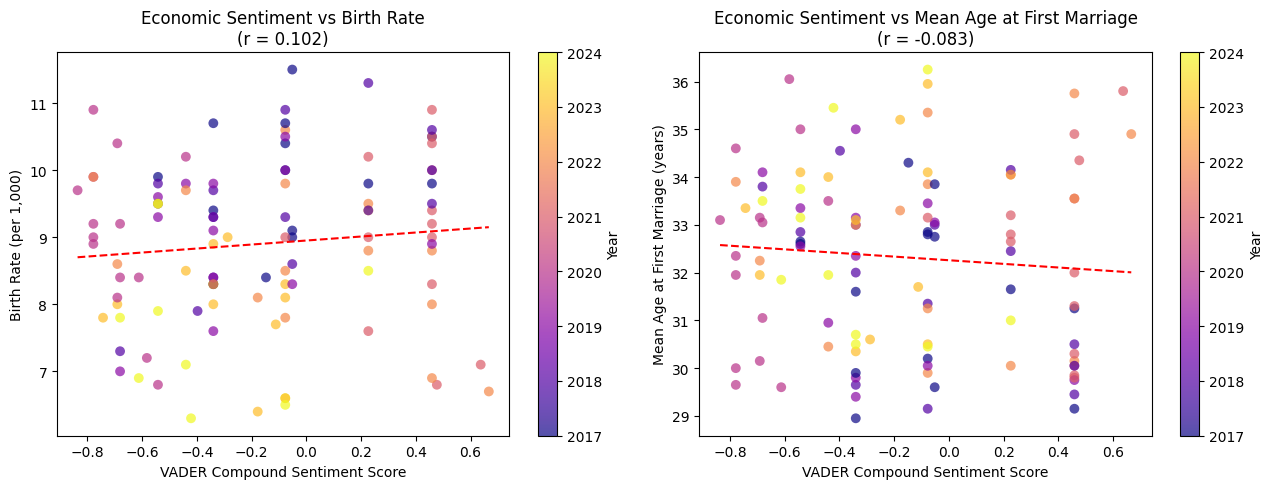

Saved nlp_sentiment_vs_outcomes.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, target, label, unit in zip(
    axes,
    ['birth_rate', 'mean_age_first_marriage'],
    ['Birth Rate', 'Mean Age at First Marriage'],
    ['per 1,000', 'years']
):
    sc = ax.scatter(
        df['sent_compound'], df[target],
        c=df['year'], cmap='plasma', alpha=0.7, edgecolors='none', s=50
    )
    plt.colorbar(sc, ax=ax, label='Year')
    z = np.polyfit(df['sent_compound'].dropna(), df.loc[df['sent_compound'].notna(), target], 1)
    x_line = np.linspace(df['sent_compound'].min(), df['sent_compound'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'r--', linewidth=1.5)
    r = df[['sent_compound', target]].corr().iloc[0, 1]
    ax.set_xlabel('VADER Compound Sentiment Score')
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_title(f'Economic Sentiment vs {label}\n(r = {r:.3f})')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nlp_sentiment_vs_outcomes.png', dpi=200)
plt.show()
print('Saved nlp_sentiment_vs_outcomes.png')

In [5]:
# ── STEP 3: TF-IDF Vectorisation ──────────────────────────────────────────────
#
# TF-IDF converts each narrative into a vector of term weights. Words that
# appear often in one document but rarely across all documents get high scores.
# This lets us represent each country-year as a point in 'economic language space'.

stop_words = stopwords.words('english')

tfidf = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    max_features=80
)

tfidf_matrix = tfidf.fit_transform(df['narrative'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print('TF-IDF matrix shape:', tfidf_df.shape)
print('Top terms by mean TF-IDF weight:')
print(tfidf_df.mean().sort_values(ascending=False).head(15).round(4))

TF-IDF matrix shape: (109, 80)
Top terms by mean TF-IDF weight:
moderate          0.1626
years             0.1010
prices            0.1010
marriage          0.1010
housing prices    0.1010
housing           0.1010
mean              0.1010
mean age          0.1010
first marriage    0.1010
first             0.1010
per               0.1010
per thousand      0.1010
persons           0.1010
experienced       0.1010
persons mean      0.1010
dtype: float64


In [6]:
# ── STEP 4: LDA Topic Modelling — Discovering Economic Regimes ────────────────
#
# LDA finds latent 'topics' (here: economic regimes) that explain the
# distribution of words across narratives. Each country-year is assigned
# a probability distribution over these regimes.

N_TOPICS = 4

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20
)
topic_matrix = lda.fit_transform(tfidf_matrix)

# Assign dominant topic to each country-year
df['topic'] = topic_matrix.argmax(axis=1)
df['topic_prob'] = topic_matrix.max(axis=1)

# Print top words per topic
feature_names = tfidf.get_feature_names_out()
topic_labels = []
print('LDA Topics (economic regimes):')
for i, comp in enumerate(lda.components_):
    top_words = [feature_names[j] for j in comp.argsort()[-8:][::-1]]
    print(f'  Topic {i}: {", ".join(top_words)}')
    topic_labels.append(f'Topic {i}')

LDA Topics (economic regimes):
  Topic 0: 10, rate 10, 10 per, strong economic, strong, prices strong, moderate inflation, experienced moderate
  Topic 1: rate per, inflation rising, experienced moderate, moderate inflation, 29, 29 years, unemployment birth, thousand
  Topic 2: rapidly, rapidly rising, inflation rapidly, high inflation, extremely, experienced extremely, extremely high, stagnant economy
  Topic 3: moderate, low, experienced low, low inflation, economic, inflation rising, rate per, prices moderate


In [7]:
# Label topics based on their economic meaning (inspect top words above)
# Topics will cluster by: high-inflation era, growth era, recession, stable-low-inflation

topic_means = df.groupby('topic')[['hicp_growth', 'hpi_growth', 'gdp_growth', 'unemp_rate',
                                    'birth_rate', 'mean_age_first_marriage']].mean().round(2)
topic_means['count'] = df.groupby('topic')['country'].count()
topic_means['year_mode'] = df.groupby('topic')['year'].apply(lambda x: x.mode()[0])
print('Mean values by LDA topic:')
print(topic_means)

Mean values by LDA topic:
       hicp_growth  hpi_growth  gdp_growth  unemp_rate  birth_rate  \
topic                                                                
0             2.84        8.47        5.24        6.74       10.30   
2             7.25        9.42        2.81        6.47        8.50   
3             2.39        6.34        1.36        7.30        8.92   

       mean_age_first_marriage  count  year_mode  
topic                                             
0                        31.03      9       2021  
2                        32.38     34       2022  
3                        32.47     66       2017  


Regime distribution:
regime
Stable-Growth     75
High-Inflation    34
Name: count, dtype: int64


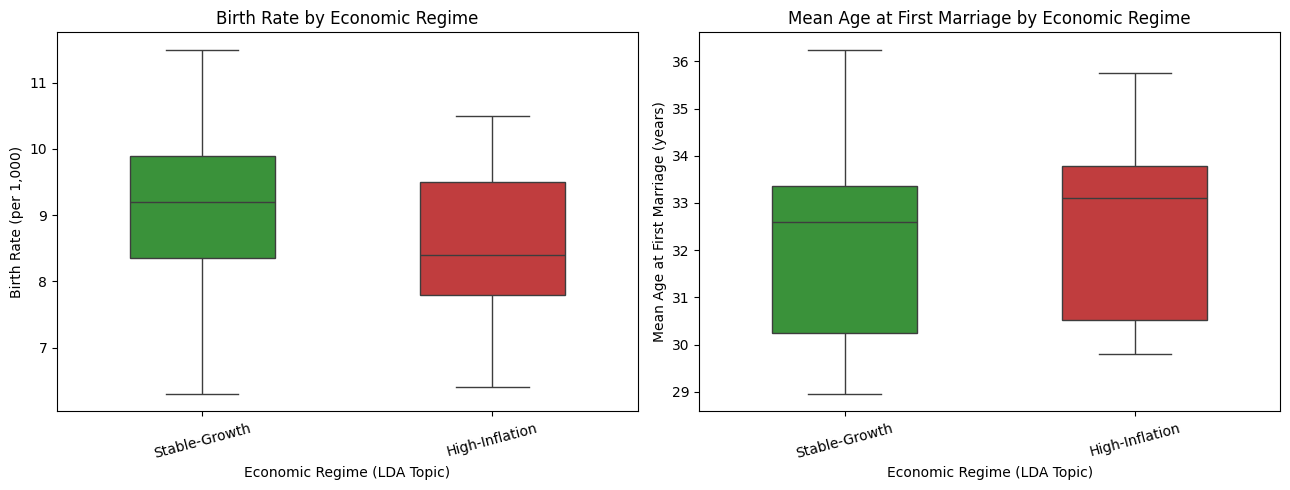

Saved nlp_regimes_vs_outcomes.png


In [8]:
# Assign human-readable regime names based on macro means
regime_map = {}
for t, row in topic_means.iterrows():
    if row['hicp_growth'] > 5:
        regime_map[t] = 'High-Inflation'
    elif row['gdp_growth'] < 0:
        regime_map[t] = 'Recession/COVID'
    elif row['unemp_rate'] > 8:
        regime_map[t] = 'High-Unemployment'
    else:
        regime_map[t] = 'Stable-Growth'

df['regime'] = df['topic'].map(regime_map)
print('Regime distribution:')
print(df['regime'].value_counts())

# Box plots: demographic outcomes by economic regime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'High-Inflation': '#d62728', 'Recession/COVID': '#ff7f0e',
           'High-Unemployment': '#9467bd', 'Stable-Growth': '#2ca02c'}

order = [r for r in ['Stable-Growth', 'High-Unemployment', 'Recession/COVID', 'High-Inflation']
         if r in df['regime'].unique()]

for ax, col, label, unit in zip(
    axes,
    ['birth_rate', 'mean_age_first_marriage'],
    ['Birth Rate', 'Mean Age at First Marriage'],
    ['per 1,000', 'years']
):
    sns.boxplot(data=df, x='regime', y=col, order=order,
                palette=palette, ax=ax, width=0.5)
    ax.set_xlabel('Economic Regime (LDA Topic)')
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_title(f'{label} by Economic Regime')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nlp_regimes_vs_outcomes.png', dpi=200)
plt.show()
print('Saved nlp_regimes_vs_outcomes.png')

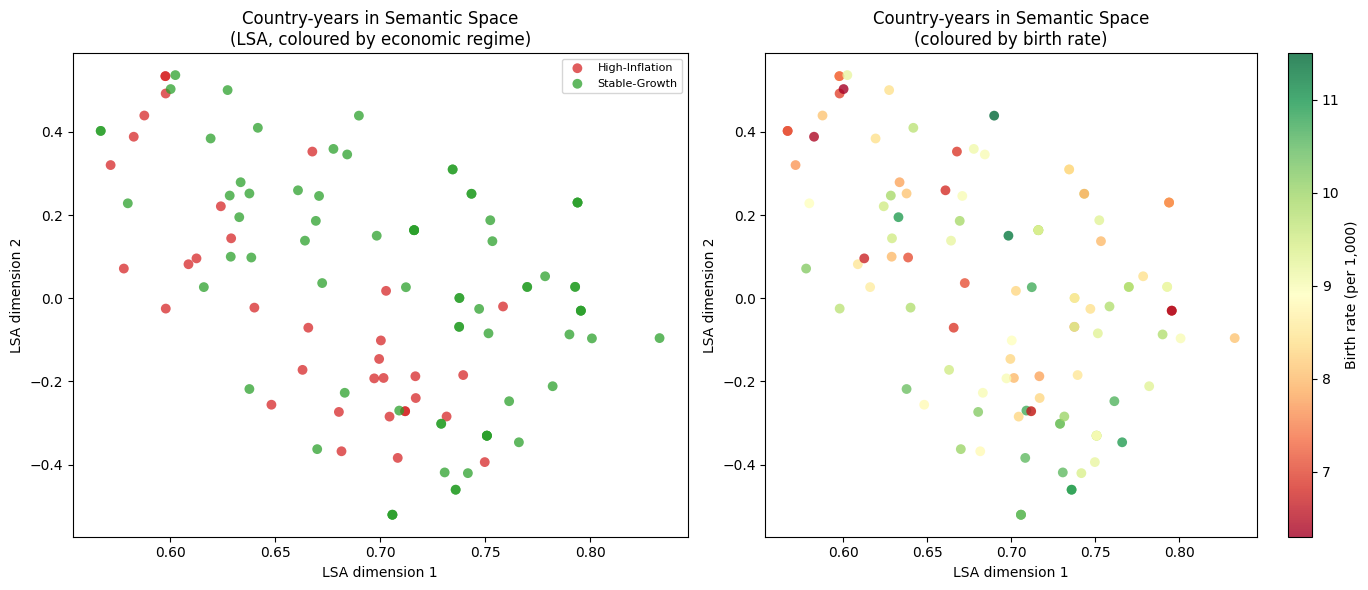

Saved nlp_lsa_embedding.png


In [9]:
# ── STEP 5: LSA Embedding — Visualise Country-Years in Semantic Space ─────────
#
# Truncated SVD (= LSA) reduces the TF-IDF matrix to 2 dimensions so we can
# plot each country-year as a point and see how economic regimes cluster.

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)
df['lsa_x'] = coords[:, 0]
df['lsa_y'] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: colour by regime
for regime, grp in df.groupby('regime'):
    axes[0].scatter(grp['lsa_x'], grp['lsa_y'], label=regime,
                    color=palette.get(regime, 'gray'), alpha=0.75, s=50, edgecolors='none')
axes[0].set_title('Country-years in Semantic Space\n(LSA, coloured by economic regime)')
axes[0].set_xlabel('LSA dimension 1')
axes[0].set_ylabel('LSA dimension 2')
axes[0].legend(fontsize=8)

# Right: colour by birth rate
sc = axes[1].scatter(df['lsa_x'], df['lsa_y'], c=df['birth_rate'],
                     cmap='RdYlGn', alpha=0.8, s=50, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Birth rate (per 1,000)')
axes[1].set_title('Country-years in Semantic Space\n(coloured by birth rate)')
axes[1].set_xlabel('LSA dimension 1')
axes[1].set_ylabel('LSA dimension 2')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nlp_lsa_embedding.png', dpi=200)
plt.show()
print('Saved nlp_lsa_embedding.png')

In [10]:
# ── STEP 6: Regression with NLP Features vs Numerical Features ────────────────
#
# Compare three feature sets on held-out years (2022-2024):
#   A) Numerical macro lags only (baseline)
#   B) NLP features only (sentiment + LSA dims + topic probs)
#   C) Combined (numerical + NLP)

train_mask = df['year'] <= 2021
test_mask  = df['year'] >= 2022

NUMERICAL = [
    'hpi_growth_lag1', 'hicp_growth_lag1', 'gdp_growth_lag1', 'unemp_rate_lag1',
    'birth_rate_lag1'
]
NLP_FEATS = ['sent_compound', 'sent_neg', 'sent_pos', 'lsa_x', 'lsa_y'] + \
            [f'topic_{i}_prob' for i in range(N_TOPICS)]

# Add topic probability columns
for i in range(N_TOPICS):
    df[f'topic_{i}_prob'] = topic_matrix[:, i]

COMBINED = NUMERICAL + ['sent_compound', 'sent_neg', 'lsa_x', 'lsa_y'] + \
           [f'topic_{i}_prob' for i in range(N_TOPICS)]

target = 'birth_rate'
results = []

for label, feats in [('Numerical only', NUMERICAL), ('NLP only', NLP_FEATS), ('Numerical + NLP', COMBINED)]:
    sub = df[feats + [target]].dropna()
    tr  = sub[train_mask[sub.index]]
    te  = sub[test_mask[sub.index]]
    if len(tr) == 0 or len(te) == 0:
        continue
    sc  = StandardScaler().fit(tr[feats])
    m   = Ridge(alpha=1.0).fit(sc.transform(tr[feats]), tr[target])
    y_hat = m.predict(sc.transform(te[feats]))
    rmse  = np.sqrt(mean_squared_error(te[target], y_hat))
    r2    = r2_score(te[target], y_hat)
    print(f'{label:<22}  RMSE={rmse:.4f}  R²={r2:.4f}')
    results.append({'Features': label, 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})

pd.DataFrame(results).to_csv(DATA_PROCESSED / 'nlp_model_comparison.csv', index=False)

Numerical only          RMSE=0.4163  R²=0.8496
NLP only                RMSE=1.3806  R²=-0.6537
Numerical + NLP         RMSE=0.4415  R²=0.8309


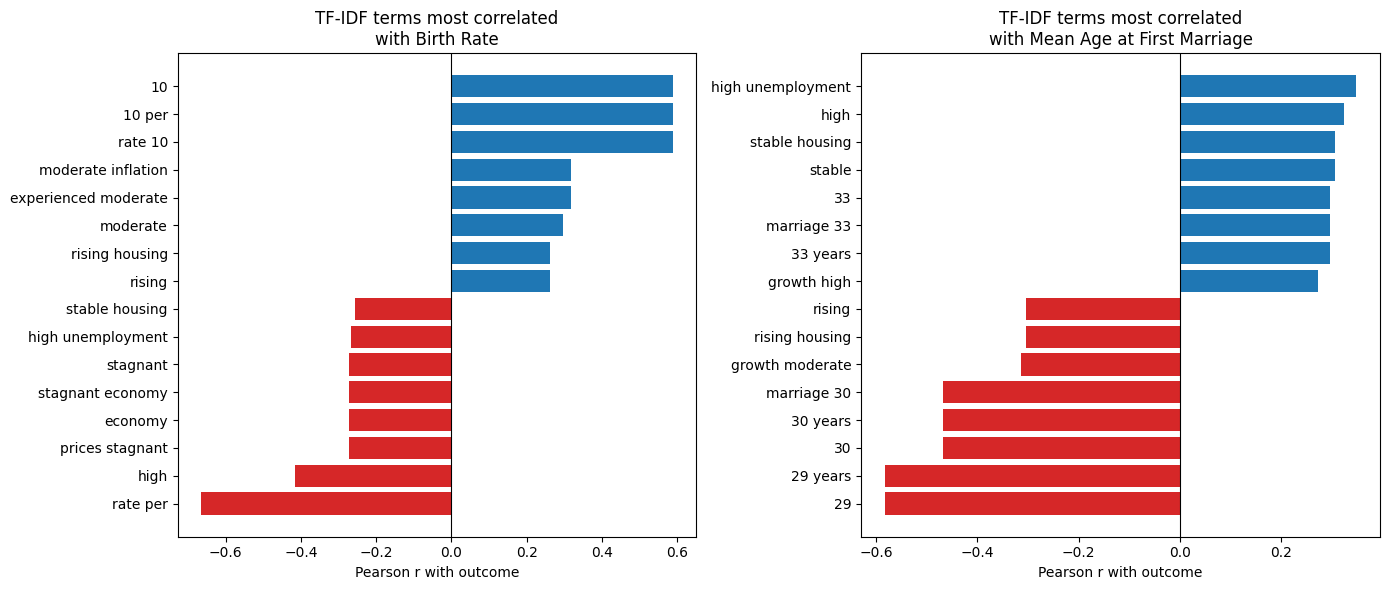

Saved nlp_tfidf_term_correlations.png


In [11]:
# ── STEP 7: Most Discriminative TF-IDF Terms per Outcome ─────────────────────
#
# Compute Pearson correlation of each TF-IDF term weight with birth rate and
# marriage age. Top positive/negative terms reveal which economic language
# is most associated with each demographic outcome.

tfidf_dense = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, outcome, label in zip(
    axes,
    ['birth_rate', 'mean_age_first_marriage'],
    ['Birth Rate', 'Mean Age at First Marriage']
):
    corrs = tfidf_dense.corrwith(df[outcome]).dropna().sort_values()
    top = pd.concat([corrs.head(8), corrs.tail(8)])
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in top.values]
    ax.barh(top.index, top.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'TF-IDF terms most correlated\nwith {label}')
    ax.set_xlabel('Pearson r with outcome')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nlp_tfidf_term_correlations.png', dpi=200)
plt.show()
print('Saved nlp_tfidf_term_correlations.png')

In [12]:
# ── SUMMARY ───────────────────────────────────────────────────────────────────
print('=== NLP Analysis Summary ===')
print()
print('1. VADER sentiment scores correlate with birth rate:')
r_sent = df[['sent_compound','birth_rate']].corr().iloc[0,1]
print(f'   r(sentiment, birth_rate) = {r_sent:.3f}')
print()
print('2. LDA economic regimes and mean birth rates:')
print(df.groupby('regime')['birth_rate'].mean().round(3).to_string())
print()
print('3. LDA economic regimes and mean marriage age:')
print(df.groupby('regime')['mean_age_first_marriage'].mean().round(3).to_string())
print()
print('4. Model comparison saved to data/processed/nlp_model_comparison.csv')

=== NLP Analysis Summary ===

1. VADER sentiment scores correlate with birth rate:
   r(sentiment, birth_rate) = 0.102

2. LDA economic regimes and mean birth rates:
regime
High-Inflation    8.503
Stable-Growth     9.081

3. LDA economic regimes and mean marriage age:
regime
High-Inflation    32.384
Stable-Growth     32.294

4. Model comparison saved to data/processed/nlp_model_comparison.csv
